In [12]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load the data
df = pd.read_csv(r"C:\Users\Robert\OneDrive\Desktop\DIY Java\ds-studio-ii\DataSets\student-por.csv")

In [ ]:
# Do a quick dummy check
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
# Remove unnecrssary columns
df = df.drop(columns=["freetime", "goout", "Walc", "famrel", "freetime", "goout", "Pstatus", "Medu", "Fedu", "address", "famsize", "guardian", "traveltime", "nursery", "internet", "romantic", "health", "reason", "Dalc", "paid", "activities"])
df.head()

,school,sex,age,Mjob,Fjob,studytime,failures,schoolsup,famsup,higher,absences,G1,G2,G3
0,GP,F,18,at_home,teacher,2,0,yes,no,yes,4,0,11,11
1,GP,F,17,at_home,other,2,0,no,yes,yes,2,9,11,11
2,GP,F,15,at_home,other,2,0,yes,no,yes,6,12,13,12
3,GP,F,15,health,services,3,0,no,yes,yes,0,14,14,14
4,GP,F,16,other,other,2,0,no,yes,yes,0,11,13,13


In [ ]:
# Ensure no data manipulation needs to happen
df.info()
df["schoolsup"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   school     649 non-null    object
 1   sex        649 non-null    object
 2   age        649 non-null    int64 
 3   Mjob       649 non-null    object
 4   Fjob       649 non-null    object
 5   studytime  649 non-null    int64 
 6   failures   649 non-null    int64 
 7   schoolsup  649 non-null    object
 8   famsup     649 non-null    object
 9   higher     649 non-null    object
 10  absences   649 non-null    int64 
 11  G1         649 non-null    int64 
 12  G2         649 non-null    int64 
 13  G3         649 non-null    int64 
dtypes: int64(7), object(7)
memory usage: 71.1+ KB


schoolsup
no     581
yes     68
Name: count, dtype: int64

In [ ]:
# Comparing mean final grades between those who did and did not participate in the in-school support programs
df.groupby("schoolsup")["G3"].mean()

schoolsup
no     11.979346
yes    11.279412
Name: G3, dtype: float64

In [ ]:
# Comparing mean number of failed classes prior to being eligible to participate
df.groupby("schoolsup")["failures"].mean()

schoolsup
no     0.222031
yes    0.220588
Name: failures, dtype: float64

In [ ]:
# Comparing the beginning and final grades of students who did participate, and those of students who did not participate
df.groupby("schoolsup")[["G1","G3"]].mean()

,G1,G3
schoolsup,,
no,11.466437,11.979346
yes,10.823529,11.279412


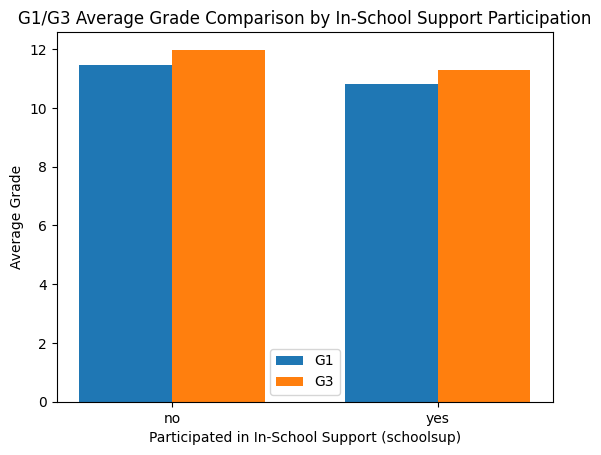

In [ ]:
# Visualizing the grouped bar charts to compare initial and final grades for either group
# Group by school support participation
means = df.groupby("schoolsup")[["G1", "G3"]].mean()

# Get group labels (yes / no)
groups = means.index.tolist()

# X positions
x = np.arange(len(groups))
width = 0.35

plt.figure()

# Plot bars
plt.bar(x - width/2, means["G1"], width, label="G1")
plt.bar(x + width/2, means["G3"], width, label="G3")

# Labels
plt.xticks(x, groups)
plt.xlabel("Participated in In-School Support (schoolsup)")
plt.ylabel("Average Grade")
plt.title("G1/G3 Average Grade Comparison by In-School Support Participation")
plt.legend()

plt.show()

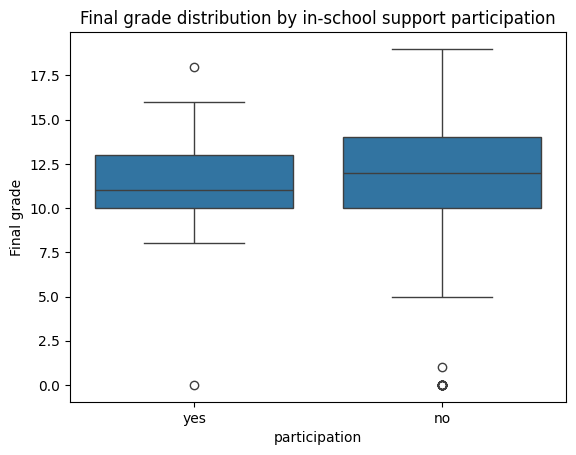

In [ ]:
# Visualizing the big 5 for each category
sns.boxplot(x="schoolsup", y="G3", data=df)

plt.title("Final grade (G3) distribution by in-school support participation")
plt.xlabel("Participation")
plt.ylabel("Final grade")

plt.show()